# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 11 — Constrained Redistribution & Final Architecture Selection

Block 11 is the **final architecture experiment**.

It does not modify the frozen signal logic. It addresses the portfolio-construction weakness identified in Block 10: unconstrained exit-and-redistribute can occasionally concentrate 100% of the portfolio in a single surviving sector.

The predeclared architectures are:

- **Canonical_Underweight** — original state-dependent portfolio from Blocks 4–8
- **Exit_Cash_1.0x** — bearish sectors exit; surviving sectors retain strategic weights; residual capital is cash
- **Constrained_1.5x** — bearish sectors exit; surviving sector weights may rise to at most 1.5× their strategic weights; any residual capital remains cash
- **Constrained_2.0x** — same, with a 2.0× cap
- **Unconstrained_Redistribute** — Block 10 extension; bearish sectors exit and all capital is redistributed across surviving sectors when possible

Only **1.5× and 2.0×** are new constrained candidates. The 1.0× and unconstrained versions are anchor cases already motivated by prior blocks.

The comparison includes:

- gross and 5 bps net performance
- turnover and cash usage
- maximum single-sector weight
- HHI / effective number of sectors
- subperiod robustness
- leave-one-sector-out robustness
- transaction-cost sensitivity
- identical-sample comparison with SPY
- a final architecture decision table

No signal parameters are optimized.


In [1]:
# ============================================================
# BLOCK 11.1 — ENVIRONMENT, DRIVE & MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path(r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

def load_manifest(filename):
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block1 = load_manifest("block_1_research_configuration.json")
block2 = load_manifest("block_2_universe_data_weights.json")
block4 = load_manifest("block_4_state_active_weights.json")
block5 = load_manifest("block_5_portfolio_engine.json")
block8 = load_manifest("block_8_robustness_costs_sensitivity.json")
block10 = load_manifest("block_10_exit_redistribute_audit_robustness.json")

SECTOR_RECORDS = block1["sector_universe"]
SECTOR_COLS = [x["ticker"] for x in SECTOR_RECORDS]
assert len(SECTOR_COLS) == 11

print("Loaded required manifests through Block 10.")


Mounted at /content/drive
Loaded required manifests through Block 10.


In [2]:
# ============================================================
# BLOCK 11.2 — IMPORTS & SOURCE DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)


def resolve_path(mapping, keys, label, filename_tokens=None):
    """
    Resolve a saved artifact robustly.

    First try the expected manifest keys. If those are absent, scan the
    manifest values for a filename containing all requested tokens. This
    protects Block 11 from harmless naming differences between earlier
    block manifests.
    """
    # 1. Exact key lookup.
    for key in keys:
        if key in mapping:
            p = Path(mapping[key])
            if p.exists():
                return p

    # 2. Filename-token fallback.
    if filename_tokens:
        tokens = [str(t).lower() for t in filename_tokens]

        for key, value in mapping.items():
            try:
                p = Path(value)
            except TypeError:
                continue

            name = p.name.lower()

            if all(token in name for token in tokens) and p.exists():
                print(
                    f"Resolved {label} by filename fallback: "
                    f"manifest key='{key}', file='{p.name}'"
                )
                return p

    raise FileNotFoundError(
        f"Could not resolve {label}.\n"
        f"Tried manifest keys: {keys}\n"
        f"Filename tokens: {filename_tokens}\n"
        f"Available saved_files keys: {list(mapping.keys())}\n"
        f"Available saved_files values: {list(mapping.values())}"
    )


STRATEGIC_PATH = resolve_path(
    block2["saved_files"],
    ["strategic_weights", "weekly_strategic_weights"],
    "strategic weights",
    filename_tokens=["strategic", "weights"],
)

STATE_PATH = resolve_path(
    block4["saved_files"],
    [
        "canonical_active_weights_long",
        "active_weights_long",
        "weekly_state_dependent_active_weights_long",
        "state_active_weights_long",
    ],
    "weekly state table",
    filename_tokens=["active", "weights", "long"],
)

CANONICAL_WEIGHT_PATH = resolve_path(
    block4["saved_files"],
    [
        "target_weights",
        "state_dependent_target_weights",
        "weekly_state_dependent_target_weights",
        "canonical_target_weights",
        "weekly_target_weights",
    ],
    "canonical state-dependent target weights",
    filename_tokens=["target", "weights"],
)

SECTOR_RETURNS_PATH = resolve_path(
    block5["saved_files"],
    [
        "sector_holding_returns",
        "weekly_execution_holding_returns_sectors",
        "holding_returns_sectors",
    ],
    "weekly sector holding returns",
    filename_tokens=["holding", "returns", "sectors"],
)

CORE_RETURNS_PATH = resolve_path(
    block5["saved_files"],
    [
        "portfolio_returns",
        "weekly_portfolio_returns_core_strategies",
        "core_strategy_returns",
    ],
    "core strategy returns",
    filename_tokens=["portfolio", "returns", "core"],
)

CORE_TURNOVER_PATH = resolve_path(
    block5["saved_files"],
    [
        "portfolio_turnover",
        "weekly_portfolio_turnover_core_strategies",
        "core_strategy_turnover",
    ],
    "core strategy turnover",
    filename_tokens=["portfolio", "turnover", "core"],
)


print("\nResolved source artifacts:")
print("Strategic weights:", STRATEGIC_PATH)
print("Weekly state table:", STATE_PATH)
print("Canonical target weights:", CANONICAL_WEIGHT_PATH)
print("Sector holding returns:", SECTOR_RETURNS_PATH)
print("Core portfolio returns:", CORE_RETURNS_PATH)
print("Core portfolio turnover:", CORE_TURNOVER_PATH)


strategic = pd.read_parquet(STRATEGIC_PATH)
state_long = pd.read_parquet(STATE_PATH)
canonical_weights = pd.read_parquet(CANONICAL_WEIGHT_PATH)
sector_returns = pd.read_parquet(SECTOR_RETURNS_PATH)
core_returns = pd.read_parquet(CORE_RETURNS_PATH)
core_turnover = pd.read_parquet(CORE_TURNOVER_PATH)

for df in [
    strategic,
    canonical_weights,
    sector_returns,
    core_returns,
    core_turnover,
]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

state_long["date"] = pd.to_datetime(state_long["date"])
state_long.sort_values(["ticker", "date"], inplace=True)

print("\nState columns:", list(state_long.columns))
print("Core strategies:", list(core_returns.columns))


Resolved canonical state-dependent target weights by filename fallback: manifest key='canonical_target_weights_wide', file='weekly_state_dependent_target_weights.parquet'

Resolved source artifacts:
Strategic weights: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_signal_strategic_sector_weights.parquet
Weekly state table: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_active_weights_long.parquet
Canonical target weights: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_target_weights.parquet
Sector holding returns: /conten

In [3]:
# ============================================================
# BLOCK 11.3 — METRIC HELPERS
# ============================================================

PPY = 52
COST_SCENARIOS_BPS = [0, 5, 10, 20]

def cagr(r):
    if len(r) == 0:
        return np.nan
    terminal = float((1 + r).prod())
    years = len(r) / PPY
    return terminal ** (1 / years) - 1 if terminal > 0 and years > 0 else np.nan

def ann_vol(r):
    return float(r.std(ddof=1) * np.sqrt(PPY))

def sharpe(r):
    sd = r.std(ddof=1)
    return np.nan if sd == 0 or pd.isna(sd) else float(r.mean() / sd * np.sqrt(PPY))

def sortino(r):
    d = r[r < 0]
    if len(d) == 0:
        return np.nan
    ddev = np.sqrt((d ** 2).mean())
    return np.nan if ddev == 0 or pd.isna(ddev) else float(r.mean() / ddev * np.sqrt(PPY))

def drawdown_series(r):
    wealth = (1 + r).cumprod()
    return wealth / wealth.cummax() - 1

def max_drawdown(r):
    return float(drawdown_series(r).min())

def calmar(r):
    g = cagr(r)
    mdd = max_drawdown(r)
    return np.nan if mdd == 0 or pd.isna(mdd) else float(g / abs(mdd))

def information_ratio(active):
    te = active.std(ddof=1)
    return np.nan if te == 0 or pd.isna(te) else float(active.mean() / te * np.sqrt(PPY))

def summarize(r):
    return {
        "Cumulative Return": float((1 + r).prod() - 1),
        "CAGR": cagr(r),
        "Annualized Volatility": ann_vol(r),
        "Sharpe": sharpe(r),
        "Sortino": sortino(r),
        "Max Drawdown": max_drawdown(r),
        "Calmar": calmar(r),
        "Terminal Wealth": float((1 + r).prod()),
    }

def normalize_rows(df):
    total = df.sum(axis=1)
    return df.div(total.replace(0, np.nan), axis=0)


In [4]:
# ============================================================
# BLOCK 11.4 — RECONSTRUCT STRATEGIC HELD STATE
# ============================================================

if "positionHeld" in state_long.columns:
    held_long = state_long[["date", "ticker", "positionHeld"]].copy()
    held_long["positionHeld"] = held_long["positionHeld"].astype(bool)

elif "position_held" in state_long.columns:
    held_long = state_long[["date", "ticker", "position_held"]].copy()
    held_long.rename(columns={"position_held": "positionHeld"}, inplace=True)
    held_long["positionHeld"] = held_long["positionHeld"].astype(bool)

else:
    if "strategic_state" not in state_long.columns:
        raise ValueError("Cannot reconstruct positionHeld from Block 4.")
    held_long = state_long[["date", "ticker", "strategic_state"]].copy()
    held_long["positionHeld"] = held_long["strategic_state"] != "BEARISH"

held = (
    held_long
    .pivot(index="date", columns="ticker", values="positionHeld")
    .sort_index()
    .reindex(columns=SECTOR_COLS)
    .astype(float)
)

assert held.isin([0.0, 1.0]).all().all()

print("Held-state reconstruction passed.")
print("Minimum sectors held:", int(held.sum(axis=1).min()))
print("Maximum sectors held:", int(held.sum(axis=1).max()))


Held-state reconstruction passed.
Minimum sectors held: 0
Maximum sectors held: 9


In [5]:
# ============================================================
# BLOCK 11.5 — CONSTRAINED REDISTRIBUTION ENGINE
# ============================================================

def constrained_exit_weights(base_weights, held_matrix, cap_multiple):
    """
    Bearish sectors receive zero weight.

    Surviving sectors are scaled proportionally to their strategic weights,
    subject to a maximum of cap_multiple × strategic weight.

    Because the same cap multiple applies to every surviving sector, the
    proportional solution is exact:
        scale = min(1 / surviving_strategic_mass, cap_multiple)

    Any residual allocation remains in cash.
    """

    idx = base_weights.index.intersection(held_matrix.index)
    base = base_weights.reindex(idx)[SECTOR_COLS]
    h = held_matrix.reindex(idx)[SECTOR_COLS]

    held_base = base.where(h > 0.5, 0.0)
    held_mass = held_base.sum(axis=1)

    if np.isinf(cap_multiple):
        scale = pd.Series(
            np.where(held_mass > 0, 1.0 / held_mass, 0.0),
            index=idx,
        )
    else:
        scale = pd.Series(
            np.where(
                held_mass > 0,
                np.minimum(1.0 / held_mass, cap_multiple),
                0.0,
            ),
            index=idx,
        )

    weights = held_base.mul(scale, axis=0)
    cash = (1.0 - weights.sum(axis=1)).clip(lower=0.0, upper=1.0)
    cash.name = "CASH"

    # Core safety checks.
    if (weights < -1e-12).any().any():
        raise AssertionError("Negative portfolio weight detected.")

    if ((weights.sum(axis=1) + cash) - 1.0).abs().max() > 1e-10:
        raise AssertionError("Weights plus cash do not sum to 1.")

    if not np.isinf(cap_multiple):
        cap_matrix = base * cap_multiple
        breach = (weights - cap_matrix) > 1e-10
        if breach.any().any():
            raise AssertionError(f"{cap_multiple}x strategic cap breached.")

    return weights, cash


ARCHITECTURES = {
    "Exit_Cash_1.0x": 1.0,
    "Constrained_1.5x": 1.5,
    "Constrained_2.0x": 2.0,
    "Unconstrained_Redistribute": np.inf,
}

architecture_weights = {}
architecture_cash = {}

for name, cap in ARCHITECTURES.items():
    w, c = constrained_exit_weights(
        strategic,
        held,
        cap,
    )
    architecture_weights[name] = w
    architecture_cash[name] = c

print("Constructed constrained redistribution architectures.")


Constructed constrained redistribution architectures.


In [6]:
# ============================================================
# BLOCK 11.6 — IDENTICAL REALIZED SAMPLE
# ============================================================

# Start from the canonical realized sector-return window.
common_idx = sector_returns.index.copy()

for name, w in architecture_weights.items():
    common_idx = common_idx.intersection(w.index)

common_idx = common_idx.intersection(canonical_weights.index)
common_idx = common_idx.intersection(core_returns.index)

sector_r = sector_returns.reindex(common_idx)[SECTOR_COLS]
strategic_realized = strategic.reindex(common_idx)[SECTOR_COLS]

print("Common realized observations:", len(common_idx))
print("Start:", common_idx.min().date())
print("End:", common_idx.max().date())


Common realized observations: 374
Start: 2019-06-21
End: 2026-08-14


In [7]:
# ============================================================
# BLOCK 11.7 — RETURNS & TURNOVER
# ============================================================

returns = pd.DataFrame(index=common_idx)
turnover = pd.DataFrame(index=common_idx)
cash_usage = pd.DataFrame(index=common_idx)

# Canonical underweight.
cw = canonical_weights.reindex(common_idx)[SECTOR_COLS]
returns["Canonical_Underweight"] = (cw * sector_r).sum(axis=1)
turnover["Canonical_Underweight"] = (
    0.5 * cw.diff().abs().sum(axis=1).fillna(0.0)
)
cash_usage["Canonical_Underweight"] = 0.0

# Exit architectures.
for name in ARCHITECTURES:
    w = architecture_weights[name].reindex(common_idx)[SECTOR_COLS]
    c = architecture_cash[name].reindex(common_idx).fillna(0.0)

    returns[name] = (w * sector_r).sum(axis=1) + c * 0.0

    turnover[name] = (
        0.5 * w.diff().abs().sum(axis=1).fillna(0.0)
    )

    cash_usage[name] = c

# Comparison benchmarks from Block 5.
for name in ["SPY", "Strategic_IV", "TSMOM_12M", "State_Dependent"]:
    if name in core_returns.columns:
        returns[name] = core_returns[name].reindex(common_idx)

print("Returns and turnover constructed.")


Returns and turnover constructed.


In [8]:
# ============================================================
# BLOCK 11.8 — GROSS PERFORMANCE TABLE
# ============================================================

candidate_order = [
    "SPY",
    "Strategic_IV",
    "TSMOM_12M",
    "Canonical_Underweight",
    "Exit_Cash_1.0x",
    "Constrained_1.5x",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]

rows = []

for name in candidate_order:
    r = returns[name].dropna()
    row = {"Architecture": name, **summarize(r)}

    if name != "SPY":
        row["IR_vs_SPY"] = information_ratio(
            r - returns["SPY"].reindex(r.index)
        )
    else:
        row["IR_vs_SPY"] = np.nan

    if name not in ["SPY", "Strategic_IV"]:
        row["IR_vs_Strategic"] = information_ratio(
            r - returns["Strategic_IV"].reindex(r.index)
        )
    else:
        row["IR_vs_Strategic"] = np.nan

    if name in turnover.columns:
        row["Annualized Turnover Approx"] = turnover[name].mean() * 52
        row["Mean Cash Weight"] = cash_usage[name].mean()
    else:
        row["Annualized Turnover Approx"] = np.nan
        row["Mean Cash Weight"] = np.nan

    rows.append(row)

gross_summary = pd.DataFrame(rows).set_index("Architecture")
display(gross_summary)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Terminal Wealth,IR_vs_SPY,IR_vs_Strategic,Annualized Turnover Approx,Mean Cash Weight
Architecture,,,,,,,,,,,,
SPY,1.879664,0.158419,0.186192,0.883955,0.825773,-0.334003,0.474304,2.879664,NaN,NaN,NaN,NaN
Strategic_IV,1.343816,0.125727,0.171515,0.777031,0.680130,-0.351040,0.358157,2.343816,-0.521742,NaN,NaN,NaN
TSMOM_12M,1.350249,0.126156,0.168967,0.788368,0.694136,-0.345465,0.365178,2.350249,-0.524259,-0.007002,NaN,NaN
Canonical_Underweight,1.559913,0.139616,0.173575,0.840655,0.741352,-0.351040,0.397722,2.559913,-0.298084,0.781392,0.613680,0.000000
Exit_Cash_1.0x,0.683687,0.075125,0.070102,1.069123,0.910059,-0.091613,0.820017,1.683687,-0.590179,-0.422322,0.293016,0.529724
Constrained_1.5x,1.060334,0.105730,0.099761,1.058487,0.901779,-0.127713,0.827870,2.060334,-0.409573,-0.209518,0.438873,0.342778
Constrained_2.0x,1.294736,0.122420,0.112735,1.082000,0.937889,-0.135687,0.902220,2.294736,-0.301335,-0.086795,0.566949,0.260822
Unconstrained_Redistribute,1.834537,0.155878,0.147510,1.057434,0.908056,-0.172295,0.904716,2.834537,-0.059410,0.169921,1.090629,0.139037


In [9]:
# ============================================================
# BLOCK 11.9 — 5 BPS NET PERFORMANCE
# ============================================================

rows = []

for name in [
    "Canonical_Underweight",
    "Exit_Cash_1.0x",
    "Constrained_1.5x",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]:
    gross = returns[name].dropna()
    net = gross - turnover[name].reindex(gross.index).fillna(0.0) * 5 / 10000.0

    row = {
        "Architecture": name,
        **summarize(net),
        "Annualized Turnover Approx": turnover[name].mean() * 52,
        "Mean Cash Weight": cash_usage[name].mean(),
        "IR_vs_SPY": information_ratio(
            net - returns["SPY"].reindex(net.index)
        ),
        "IR_vs_Strategic": information_ratio(
            net - returns["Strategic_IV"].reindex(net.index)
        ),
    }
    rows.append(row)

net5_summary = pd.DataFrame(rows).set_index("Architecture")
display(net5_summary)


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Terminal Wealth,Annualized Turnover Approx,Mean Cash Weight,IR_vs_SPY,IR_vs_Strategic
Architecture,,,,,,,,,,,,
Canonical_Underweight,1.554287,0.139268,0.173573,0.838896,0.739687,-0.351073,0.396691,2.554287,0.613680,0.000000,-0.302969,0.762368
Exit_Cash_1.0x,0.681918,0.074967,0.070100,1.067066,0.908153,-0.091646,0.818014,1.681918,0.293016,0.529724,-0.591139,-0.423382
Constrained_1.5x,1.057096,0.105488,0.099758,1.056321,0.899775,-0.127757,0.825696,2.057096,0.438873,0.342778,-0.411092,-0.211179
Constrained_2.0x,1.290078,0.122103,0.112731,1.079519,0.935550,-0.136053,0.897464,2.290078,0.566949,0.260822,-0.303335,-0.088973
Unconstrained_Redistribute,1.823403,0.155246,0.147529,1.053599,0.904272,-0.172698,0.898943,2.823403,1.090629,0.139037,-0.063170,0.165828


In [10]:
# ============================================================
# BLOCK 11.10 — CONCENTRATION DIAGNOSTICS
# ============================================================

concentration_rows = []
concentration_timeseries = {}

# Canonical included for reference.
all_weight_sets = {
    "Canonical_Underweight": cw,
    **{
        name: architecture_weights[name].reindex(common_idx)[SECTOR_COLS]
        for name in ARCHITECTURES
    },
}

for name, w in all_weight_sets.items():
    c = cash_usage[name].reindex(common_idx).fillna(0.0)

    diag = pd.DataFrame(index=common_idx)
    diag["Sectors_Held"] = (w > 1e-12).sum(axis=1)
    diag["Max_Sector_Weight"] = w.max(axis=1)
    diag["HHI"] = (w ** 2).sum(axis=1)
    diag["Effective_Number_of_Sectors"] = np.where(
        diag["HHI"] > 0,
        1.0 / diag["HHI"],
        0.0,
    )
    diag["Cash_Weight"] = c

    concentration_timeseries[name] = diag

    concentration_rows.append({
        "Architecture": name,
        "Mean Sectors Held": diag["Sectors_Held"].mean(),
        "Minimum Sectors Held": diag["Sectors_Held"].min(),
        "Mean Max Sector Weight": diag["Max_Sector_Weight"].mean(),
        "Maximum Single-Sector Weight": diag["Max_Sector_Weight"].max(),
        "Mean HHI": diag["HHI"].mean(),
        "Mean Effective Sectors": diag["Effective_Number_of_Sectors"].mean(),
        "Mean Cash Weight": diag["Cash_Weight"].mean(),
        "Maximum Cash Weight": diag["Cash_Weight"].max(),
        "Weeks > 40% in One Sector": int((diag["Max_Sector_Weight"] > 0.40).sum()),
        "Weeks > 50% in One Sector": int((diag["Max_Sector_Weight"] > 0.50).sum()),
        "All-Cash Weeks": int((diag["Cash_Weight"] >= 0.999999).sum()),
    })

concentration_summary = (
    pd.DataFrame(concentration_rows)
    .set_index("Architecture")
)

display(concentration_summary)


,Mean Sectors Held,Minimum Sectors Held,Mean Max Sector Weight,Maximum Single-Sector Weight,Mean HHI,Mean Effective Sectors,Mean Cash Weight,Maximum Cash Weight,Weeks > 40% in One Sector,Weeks > 50% in One Sector,All-Cash Weeks
Architecture,,,,,,,,,,,
Canonical_Underweight,11.000000,11,0.144762,0.212610,0.101246,9.913706,0.000000,0.0,0,0,0
Exit_Cash_1.0x,5.513369,0,0.096689,0.159418,0.042507,30.337813,0.529724,1.0,0,0,52
Constrained_1.5x,5.513369,0,0.137043,0.239128,0.082776,14.086855,0.342778,1.0,0,0,52
Constrained_2.0x,5.513369,0,0.157467,0.264803,0.105764,9.348340,0.260822,1.0,0,0,52
Unconstrained_Redistribute,5.513369,0,0.215875,1.000000,0.178195,5.261832,0.139037,1.0,25,23,52


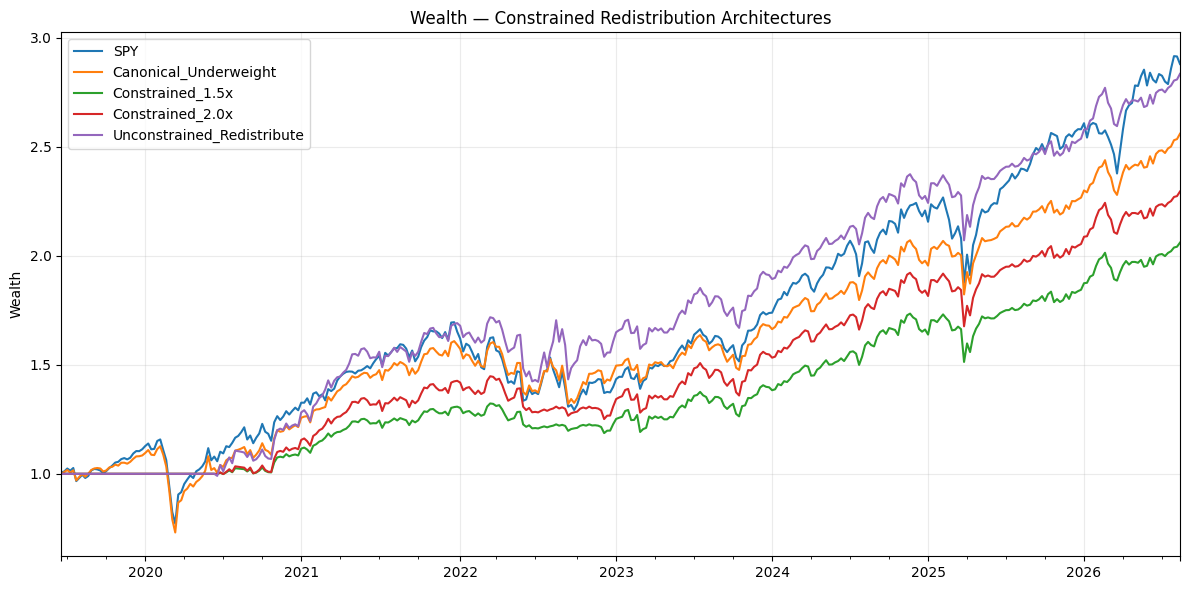

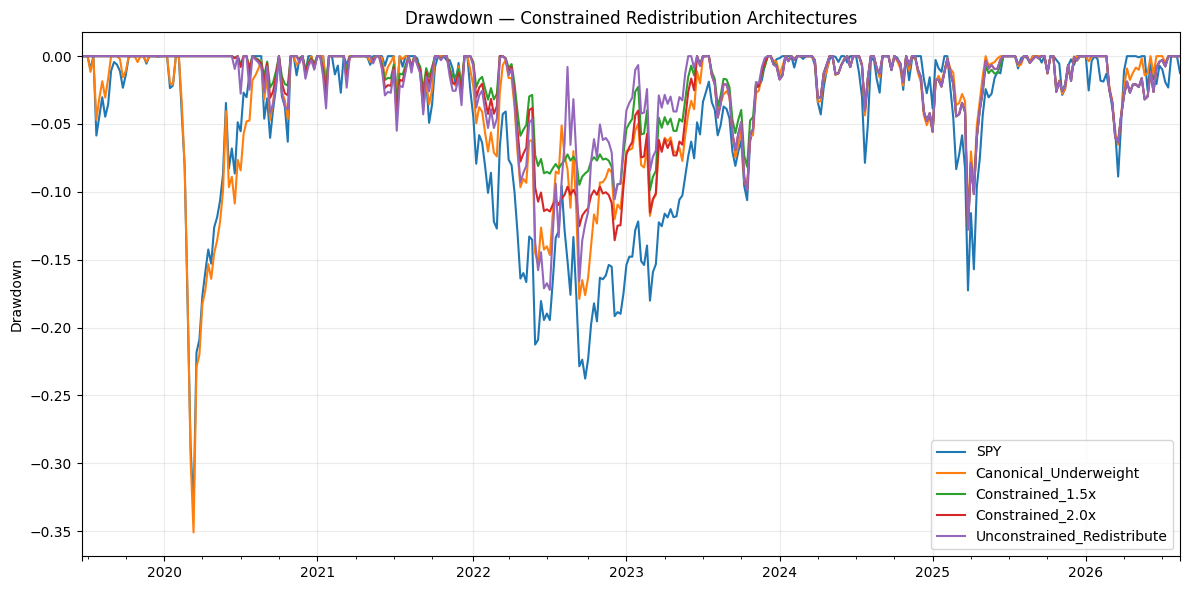

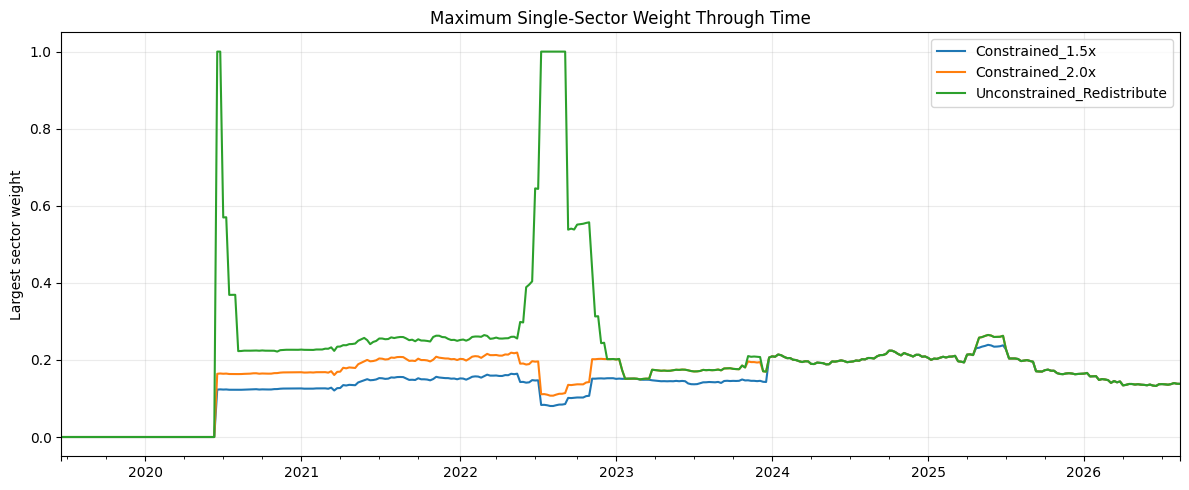

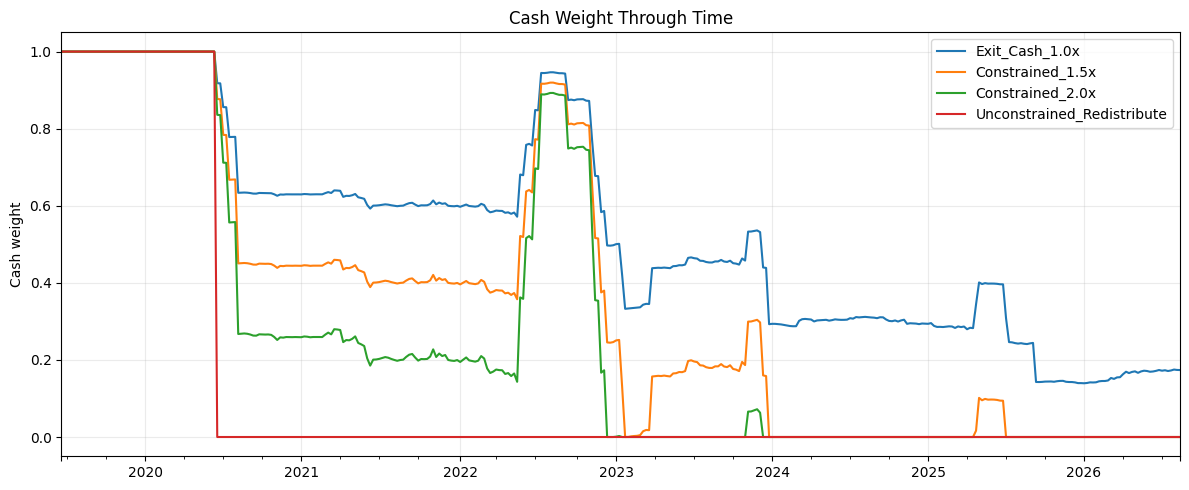

In [11]:
# ============================================================
# BLOCK 11.11 — WEALTH / DRAWDOWN / CONCENTRATION FIGURES
# ============================================================

plot_cols = [
    "SPY",
    "Canonical_Underweight",
    "Constrained_1.5x",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]

wealth = (1 + returns[plot_cols]).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
wealth.plot(ax=ax)
ax.set_title("Wealth — Constrained Redistribution Architectures")
ax.set_ylabel("Wealth")
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_WEALTH = DIRS["figures"] / "block_11_constrained_redistribution_wealth.png"
fig.savefig(FIG_WEALTH, dpi=180, bbox_inches="tight")
plt.show()

dd = pd.DataFrame({
    c: drawdown_series(returns[c])
    for c in plot_cols
})

fig, ax = plt.subplots(figsize=(12, 6))
dd.plot(ax=ax)
ax.set_title("Drawdown — Constrained Redistribution Architectures")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_DD = DIRS["figures"] / "block_11_constrained_redistribution_drawdown.png"
fig.savefig(FIG_DD, dpi=180, bbox_inches="tight")
plt.show()

max_weight_plot = pd.DataFrame({
    name: concentration_timeseries[name]["Max_Sector_Weight"]
    for name in [
        "Constrained_1.5x",
        "Constrained_2.0x",
        "Unconstrained_Redistribute",
    ]
})

fig, ax = plt.subplots(figsize=(12, 5))
max_weight_plot.plot(ax=ax)
ax.set_title("Maximum Single-Sector Weight Through Time")
ax.set_ylabel("Largest sector weight")
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_MAXW = DIRS["figures"] / "block_11_max_sector_weight_comparison.png"
fig.savefig(FIG_MAXW, dpi=180, bbox_inches="tight")
plt.show()

cash_plot = cash_usage[
    ["Exit_Cash_1.0x", "Constrained_1.5x", "Constrained_2.0x", "Unconstrained_Redistribute"]
]

fig, ax = plt.subplots(figsize=(12, 5))
cash_plot.plot(ax=ax)
ax.set_title("Cash Weight Through Time")
ax.set_ylabel("Cash weight")
ax.grid(True, alpha=0.25)
fig.tight_layout()
FIG_CASH = DIRS["figures"] / "block_11_cash_weight_comparison.png"
fig.savefig(FIG_CASH, dpi=180, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# BLOCK 11.12 — SUBPERIOD ROBUSTNESS
# ============================================================

SUBPERIODS = {
    "2019-2021": ("2019-01-01", "2021-12-31"),
    "2022-2023": ("2022-01-01", "2023-12-31"),
    "2024-End": ("2024-01-01", None),
}

sub_rows = []

sub_archs = [
    "SPY",
    "Canonical_Underweight",
    "Constrained_1.5x",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]

for label, (start, end) in SUBPERIODS.items():
    sub = returns.loc[start:end] if end else returns.loc[start:]

    for name in sub_archs:
        r = sub[name].dropna()
        if len(r) < 10:
            continue

        row = {
            "Subperiod": label,
            "Architecture": name,
            **summarize(r),
        }

        if name != "SPY":
            row["IR_vs_SPY"] = information_ratio(
                r - sub["SPY"].reindex(r.index)
            )
        else:
            row["IR_vs_SPY"] = np.nan

        sub_rows.append(row)

subperiod_summary = (
    pd.DataFrame(sub_rows)
    .set_index(["Subperiod", "Architecture"])
)

display(subperiod_summary)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  IR_vs_SPY
Subperiod Architecture                                                                                                                                          
2019-2021 SPY                                  0.652080  0.216873               0.216967  1.013794  0.890711     -0.334003  0.649314         1.652080        NaN
          Canonical_Underweight                0.591980  0.199370               0.219909  0.936869  0.798431     -0.351040  0.567940         1.591980  -0.266500
          Constrained_1.5x                     0.307943  0.110666               0.067499  1.589792  1.540723     -0.033064  3.347052         1.307943  -0.563356
          Constrained_2.0x                     0.426614  0.149027               0.089998  1.589792  1.540723     -0.044063  3.382182         1.426614  -0.386112
          Unconstrained_Redistribute           0.691099  0.228030               0.129176  1.656418  1.666263     -0.054981  4.147441         1.691099  -0.029476
2022-2023 SPY                                  0.051814  0.025580               0.183128  0.229334  0.212319     -0.205209  0.124652         1.051814        NaN
          Canonical_Underweight                0.054859  0.027063               0.168747  0.242851  0.225136     -0.176648  0.153206         1.054859  -0.021178
          Constrained_1.5x                     0.067913  0.033399               0.109684  0.354323  0.314969     -0.102802  0.324888         1.067913  -0.026813
          Constrained_2.0x                     0.084782  0.041529               0.131908  0.374326  0.337333     -0.135687  0.306061         1.084782   0.068931
          Unconstrained_Redistribute           0.130393  0.063199               0.197789  0.409523  0.359004     -0.172295  0.366810         1.130393   0.343650
2024-End  SPY                                  0.657188  0.211338               0.153895  1.324852  1.334292     -0.172681  1.223861         1.657188        NaN
          Canonical_Underweight                0.524379  0.173533               0.117852  1.418920  1.223330     -0.119879  1.447561         1.524379  -0.460234
          Constrained_1.5x                     0.475070  0.158977               0.116833  1.323173  1.141885     -0.127713  1.244798         1.475070  -0.564140
          Constrained_2.0x                     0.482804  0.161280               0.117082  1.337601  1.156516     -0.127713  1.262827         1.482804  -0.541921
          Unconstrained_Redistribute           0.482804  0.161280               0.117082  1.337601  1.156516     -0.127713  1.262827         1.482804  -0.541921

In [13]:
# ============================================================
# BLOCK 11.13 — LEAVE-ONE-SECTOR-OUT ROBUSTNESS
# ============================================================

loo_rows = []

base_realized = strategic.reindex(common_idx)[SECTOR_COLS]
held_realized = held.reindex(common_idx)[SECTOR_COLS]
sector_realized = sector_returns.reindex(common_idx)[SECTOR_COLS]

for excluded in SECTOR_COLS:
    keep = [c for c in SECTOR_COLS if c != excluded]

    base_loo = base_realized[keep]
    # Renormalize the strategic base after removing the sector.
    base_loo = normalize_rows(base_loo)

    held_loo = held_realized[keep]
    sector_r_loo = sector_realized[keep]

    strategic_r_loo = (base_loo * sector_r_loo).sum(axis=1)

    for name, cap in {
        "Constrained_1.5x": 1.5,
        "Constrained_2.0x": 2.0,
        "Unconstrained_Redistribute": np.inf,
    }.items():

        held_base = base_loo.where(held_loo > 0.5, 0.0)
        held_mass = held_base.sum(axis=1)

        if np.isinf(cap):
            scale = pd.Series(
                np.where(held_mass > 0, 1.0 / held_mass, 0.0),
                index=common_idx,
            )
        else:
            scale = pd.Series(
                np.where(
                    held_mass > 0,
                    np.minimum(1.0 / held_mass, cap),
                    0.0,
                ),
                index=common_idx,
            )

        w = held_base.mul(scale, axis=0)
        r = (w * sector_r_loo).sum(axis=1)

        loo_rows.append({
            "Excluded_Sector": excluded,
            "Architecture": name,
            "CAGR": cagr(r),
            "Sharpe": sharpe(r),
            "Sortino": sortino(r),
            "Max Drawdown": max_drawdown(r),
            "Calmar": calmar(r),
            "IR_vs_Strategic_LOO": information_ratio(
                r - strategic_r_loo
            ),
            "Terminal Wealth": float((1 + r).prod()),
            "Maximum Single-Sector Weight": float(w.max(axis=1).max()),
            "Mean Cash Weight": float((1.0 - w.sum(axis=1)).clip(0, 1).mean()),
        })

loo_summary = (
    pd.DataFrame(loo_rows)
    .set_index(["Excluded_Sector", "Architecture"])
    .sort_index()
)

display(loo_summary)


CAGR    Sharpe   Sortino  Max Drawdown    Calmar  IR_vs_Strategic_LOO  Terminal Wealth  Maximum Single-Sector Weight  Mean Cash Weight
Excluded_Sector Architecture                                                                                                                                                          
XLB             Constrained_1.5x            0.105535  1.108070  0.947423     -0.127713  0.826342            -0.215242         2.057721                      0.262288          0.371869
                Constrained_2.0x            0.121559  1.129680  0.981573     -0.127713  0.951813            -0.099842         2.282109                      0.264803          0.294501
                Unconstrained_Redistribute  0.153329  1.042655  0.889512     -0.160606  0.954690             0.147030         2.789891                      1.000000          0.144385
XLC             Constrained_1.5x            0.098235  0.970705  0.853875     -0.130481  0.752870            -0.251790         1.961974                      0.262898          0.334169
                Constrained_2.0x            0.115146  0.984785  0.879691     -0.149376  0.770851            -0.125784         2.189906                      0.311602          0.238153
                Unconstrained_Redistribute  0.146500  0.998367  0.885905     -0.172295  0.850287             0.110882         2.673231                      1.000000          0.139037
XLE             Constrained_1.5x            0.094943  0.980979  0.868215     -0.127026  0.747429            -0.273219         1.920068                      0.254962          0.366522
                Constrained_2.0x            0.107975  0.992607  0.885711     -0.166812  0.647289            -0.176260         2.090614                      0.264803          0.287882
                Unconstrained_Redistribute  0.116174  0.866153  0.751289     -0.312510  0.371745            -0.091635         2.204459                      1.000000          0.163102
XLF             Constrained_1.5x            0.107702  1.109915  0.962614     -0.127713  0.843314            -0.184574         2.086914                      0.259875          0.354095
                Constrained_2.0x            0.122674  1.137337  0.999486     -0.127713  0.960540            -0.075657         2.298470                      0.264803          0.286498
                Unconstrained_Redistribute  0.159992  1.092884  0.946702     -0.161217  0.992403             0.211518         2.907907                      1.000000          0.139037
XLI             Constrained_1.5x            0.097838  1.030967  0.831455     -0.122283  0.800091            -0.252734         1.956876                      0.260372          0.378883
                Constrained_2.0x            0.114044  1.051937  0.858469     -0.130920  0.871090            -0.133113         2.174376                      0.305437          0.295659
                Unconstrained_Redistribute  0.156840  1.053116  0.870817     -0.162624  0.964432             0.190833         2.851554                      1.000000          0.139037
XLK             Constrained_1.5x            0.104206  1.044026  0.891432     -0.119034  0.875427            -0.143665         2.039994                      0.252949          0.331412
                Constrained_2.0x            0.120209  1.043117  0.904249     -0.146472  0.820693            -0.021302         2.262421                      0.264803          0.240090
                Unconstrained_Redistribute  0.151002  1.034482  0.890548     -0.172295  0.876418             0.213531         2.749658                      1.000000          0.139037
XLP             Constrained_1.5x            0.116863  1.054079  0.920817     -0.147338  0.793161            -0.173449         2.214264                      0.198652          0.309578
                Constrained_2.0x            0.134386  1.077652  0.955123     -0.153048  0.878067            -0.048867         2.476612                      0.250944          0.226153
                Uncons

In [14]:
# ============================================================
# BLOCK 11.14 — TRANSACTION-COST SENSITIVITY
# ============================================================

cost_rows = []

for bps in COST_SCENARIOS_BPS:
    for name in [
        "Canonical_Underweight",
        "Constrained_1.5x",
        "Constrained_2.0x",
        "Unconstrained_Redistribute",
    ]:
        gross = returns[name].dropna()
        net = (
            gross
            - turnover[name].reindex(gross.index).fillna(0.0)
            * bps / 10000.0
        )

        cost_rows.append({
            "Cost_bps": bps,
            "Architecture": name,
            **summarize(net),
            "IR_vs_SPY": information_ratio(
                net - returns["SPY"].reindex(net.index)
            ),
        })

cost_summary = (
    pd.DataFrame(cost_rows)
    .set_index(["Cost_bps", "Architecture"])
)

display(cost_summary)


Cumulative Return      CAGR  Annualized Volatility    Sharpe   Sortino  Max Drawdown    Calmar  Terminal Wealth  IR_vs_SPY
Cost_bps Architecture                                                                                                                                          
0        Canonical_Underweight                1.559913  0.139616               0.173575  0.840655  0.741352     -0.351040  0.397722         2.559913  -0.298084
         Constrained_1.5x                     1.060334  0.105730               0.099761  1.058487  0.901779     -0.127713  0.827870         2.060334  -0.409573
         Constrained_2.0x                     1.294736  0.122420               0.112735  1.082000  0.937889     -0.135687  0.902220         2.294736  -0.301335
         Unconstrained_Redistribute           1.834537  0.155878               0.147510  1.057434  0.908056     -0.172295  0.904716         2.834537  -0.059410
5        Canonical_Underweight                1.554287  0.139268               0.173573  0.838896  0.739687     -0.351073  0.396691         2.554287  -0.302969
         Constrained_1.5x                     1.057096  0.105488               0.099758  1.056321  0.899775     -0.127757  0.825696         2.057096  -0.411092
         Constrained_2.0x                     1.290078  0.122103               0.112731  1.079519  0.935550     -0.136053  0.897464         2.290078  -0.303335
         Unconstrained_Redistribute           1.823403  0.155246               0.147529  1.053599  0.904272     -0.172698  0.898943         2.823403  -0.063170
10       Canonical_Underweight                1.548673  0.138919               0.173572  0.837136  0.738024     -0.351107  0.395660         2.548673  -0.307852
         Constrained_1.5x                     1.053862  0.105246               0.099755  1.054153  0.897771     -0.127800  0.823523         2.053862  -0.412611
         Constrained_2.0x                     1.285430  0.121786               0.112728  1.077038  0.933211     -0.136419  0.892735         2.285430  -0.305335
         Unconstrained_Redistribute           1.812312  0.154614               0.147549  1.049761  0.900489     -0.173101  0.893200         2.812312  -0.066930
20       Canonical_Underweight                1.537482  0.138222               0.173568  0.833618  0.734697     -0.351174  0.393601         2.537482  -0.317618
         Constrained_1.5x                     1.047410  0.104763               0.099749  1.049817  0.897390     -0.127887  0.819183         2.047410  -0.415647
         Constrained_2.0x                     1.276162  0.121152               0.112721  1.072072  0.932298     -0.137150  0.883357         2.276162  -0.309334
         Unconstrained_Redistribute           1.790255  0.153350               0.147591  1.042078  0.896550     -0.173906  0.881800         2.790255  -0.074447

In [15]:
# ============================================================
# BLOCK 11.15 — FINAL ARCHITECTURE DECISION TABLE
# ============================================================

# This table deliberately reports trade-offs rather than choosing the
# ex-post maximum-return configuration mechanically.

decision_rows = []

for name in [
    "Canonical_Underweight",
    "Exit_Cash_1.0x",
    "Constrained_1.5x",
    "Constrained_2.0x",
    "Unconstrained_Redistribute",
]:
    perf = net5_summary.loc[name]
    conc = concentration_summary.loc[name]

    if name in ["Constrained_1.5x", "Constrained_2.0x", "Unconstrained_Redistribute"]:
        loo_slice = loo_summary.xs(name, level="Architecture")
        positive_loo = int((loo_slice["IR_vs_Strategic_LOO"] > 0).sum())
        loo_total = len(loo_slice)
        worst_loo_ir = float(loo_slice["IR_vs_Strategic_LOO"].min())
    else:
        positive_loo = np.nan
        loo_total = np.nan
        worst_loo_ir = np.nan

    decision_rows.append({
        "Architecture": name,
        "Net_5bps_CAGR": perf["CAGR"],
        "Net_5bps_Sharpe": perf["Sharpe"],
        "Net_5bps_Sortino": perf["Sortino"],
        "Net_5bps_MaxDD": perf["Max Drawdown"],
        "Net_5bps_Calmar": perf["Calmar"],
        "Net_5bps_IR_vs_SPY": perf["IR_vs_SPY"],
        "Annualized_Turnover": perf["Annualized Turnover Approx"],
        "Mean_Cash_Weight": perf["Mean Cash Weight"],
        "Maximum_Single_Sector_Weight": conc["Maximum Single-Sector Weight"],
        "Weeks_Above_50pct_One_Sector": conc["Weeks > 50% in One Sector"],
        "LOO_Positive_IR_Count": positive_loo,
        "LOO_Tests": loo_total,
        "Worst_LOO_IR": worst_loo_ir,
    })

decision_table = (
    pd.DataFrame(decision_rows)
    .set_index("Architecture")
)

display(decision_table)


,Net_5bps_CAGR,Net_5bps_Sharpe,Net_5bps_Sortino,Net_5bps_MaxDD,Net_5bps_Calmar,Net_5bps_IR_vs_SPY,Annualized_Turnover,Mean_Cash_Weight,Maximum_Single_Sector_Weight,Weeks_Above_50pct_One_Sector,LOO_Positive_IR_Count,LOO_Tests,Worst_LOO_IR
Architecture,,,,,,,,,,,,,
Canonical_Underweight,0.139268,0.838896,0.739687,-0.351073,0.396691,-0.302969,0.613680,0.000000,0.212610,0.0,NaN,NaN,NaN
Exit_Cash_1.0x,0.074967,1.067066,0.908153,-0.091646,0.818014,-0.591139,0.293016,0.529724,0.159418,0.0,NaN,NaN,NaN
Constrained_1.5x,0.105488,1.056321,0.899775,-0.127757,0.825696,-0.411092,0.438873,0.342778,0.239128,0.0,0.0,11.0,-0.273219
Constrained_2.0x,0.122103,1.079519,0.935550,-0.136053,0.897464,-0.303335,0.566949,0.260822,0.264803,0.0,0.0,11.0,-0.176260
Unconstrained_Redistribute,0.155246,1.053599,0.904272,-0.172698,0.898943,-0.063170,1.090629,0.139037,1.000000,23.0,10.0,11.0,-0.091635


In [16]:
# ============================================================
# BLOCK 11.16 — PREDECLARED SELECTION FLAGS
# ============================================================

# These are not optimization rules. They are transparent guardrails for
# identifying architectures that combine improved risk-adjusted performance
# with materially reduced concentration risk.

flags = pd.DataFrame(index=decision_table.index)

flags["Sharpe_Above_Canonical"] = (
    decision_table["Net_5bps_Sharpe"]
    > decision_table.loc["Canonical_Underweight", "Net_5bps_Sharpe"]
)

flags["MaxDD_Better_Than_Canonical"] = (
    decision_table["Net_5bps_MaxDD"]
    > decision_table.loc["Canonical_Underweight", "Net_5bps_MaxDD"]
)

flags["Max_Sector_Weight_Below_50pct"] = (
    decision_table["Maximum_Single_Sector_Weight"] <= 0.50
)

flags["No_Weeks_Above_50pct"] = (
    decision_table["Weeks_Above_50pct_One_Sector"] == 0
)

# Available only for exit-redistribution candidates with LOO tests.
flags["LOO_Robust_10_of_11"] = (
    decision_table["LOO_Positive_IR_Count"] >= 10
)

display(flags)


,Sharpe_Above_Canonical,MaxDD_Better_Than_Canonical,Max_Sector_Weight_Below_50pct,No_Weeks_Above_50pct,LOO_Robust_10_of_11
Architecture,,,,,
Canonical_Underweight,False,False,True,True,False
Exit_Cash_1.0x,True,True,True,True,False
Constrained_1.5x,True,True,True,True,False
Constrained_2.0x,True,True,True,True,False
Unconstrained_Redistribute,True,True,False,False,True


In [17]:
# ============================================================
# BLOCK 11.17 — SAVE OUTPUTS
# ============================================================

TABLE_PATHS = {
    "gross_summary": DIRS["tables"] / "block_11_gross_performance.csv",
    "net5_summary": DIRS["tables"] / "block_11_net5_performance.csv",
    "concentration_summary": DIRS["tables"] / "block_11_concentration_summary.csv",
    "subperiod_summary": DIRS["tables"] / "block_11_subperiod_summary.csv",
    "leave_one_out": DIRS["tables"] / "block_11_leave_one_sector_out.csv",
    "cost_summary": DIRS["tables"] / "block_11_cost_summary.csv",
    "decision_table": DIRS["tables"] / "block_11_final_architecture_decision_table.csv",
    "selection_flags": DIRS["tables"] / "block_11_selection_flags.csv",
}

gross_summary.to_csv(TABLE_PATHS["gross_summary"])
net5_summary.to_csv(TABLE_PATHS["net5_summary"])
concentration_summary.to_csv(TABLE_PATHS["concentration_summary"])
subperiod_summary.to_csv(TABLE_PATHS["subperiod_summary"])
loo_summary.to_csv(TABLE_PATHS["leave_one_out"])
cost_summary.to_csv(TABLE_PATHS["cost_summary"])
decision_table.to_csv(TABLE_PATHS["decision_table"])
flags.to_csv(TABLE_PATHS["selection_flags"])

WEIGHT_PATHS = {}

for name in ARCHITECTURES:
    path = (
        DIRS["data_processed"]
        / f"weekly_{name.lower()}_target_weights.parquet"
    )
    architecture_weights[name].to_parquet(path)
    WEIGHT_PATHS[name] = path

RETURNS_PATH = (
    DIRS["data_processed"]
    / "block_11_candidate_architecture_returns.parquet"
)

returns.to_parquet(RETURNS_PATH)

print("Saved Block 11 outputs.")


Saved Block 11 outputs.


In [18]:
# ============================================================
# BLOCK 11.18 — MANIFEST & FINAL STATUS
# ============================================================

manifest = {
    "project": block1["project"],
    "block": "Block 11 - Constrained Redistribution & Final Architecture Selection",
    "created_utc": datetime.now(timezone.utc).isoformat(),

    "new_candidate_caps": [1.5, 2.0],

    "architectures": {
        "Canonical_Underweight": "Frozen Blocks 4-8 architecture",
        "Exit_Cash_1.0x": "Bearish sectors zero; no redistribution beyond strategic weights",
        "Constrained_1.5x": "Bearish sectors zero; surviving sectors capped at 1.5x strategic weight",
        "Constrained_2.0x": "Bearish sectors zero; surviving sectors capped at 2.0x strategic weight",
        "Unconstrained_Redistribute": "Block 10 architecture",
    },

    "cash_return_assumption": 0.0,
    "canonical_transaction_cost_bps": 5,
    "transaction_cost_scenarios_bps": COST_SCENARIOS_BPS,

    "comparison_window": {
        "start": str(common_idx.min().date()),
        "end": str(common_idx.max().date()),
        "observations": int(len(common_idx)),
    },

    "tables": {
        k: str(v)
        for k, v in TABLE_PATHS.items()
    },

    "figures": {
        "wealth": str(FIG_WEALTH),
        "drawdown": str(FIG_DD),
        "max_sector_weight": str(FIG_MAXW),
        "cash_weight": str(FIG_CASH),
    },

    "saved_files": {
        "returns": str(RETURNS_PATH),
        "candidate_weight_files": {
            k: str(v)
            for k, v in WEIGHT_PATHS.items()
        },
    },
}

MANIFEST_PATH = (
    DIRS["manifests"]
    / "block_11_constrained_redistribution_final_architecture.json"
)

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.Series({
    "New constrained candidates": 2,
    "Candidate caps": "1.5x, 2.0x",
    "5bps performance saved": TABLE_PATHS["net5_summary"].exists(),
    "Concentration diagnostics saved": TABLE_PATHS["concentration_summary"].exists(),
    "Subperiod robustness saved": TABLE_PATHS["subperiod_summary"].exists(),
    "Leave-one-out robustness saved": TABLE_PATHS["leave_one_out"].exists(),
    "Cost sensitivity saved": TABLE_PATHS["cost_summary"].exists(),
    "Decision table saved": TABLE_PATHS["decision_table"].exists(),
    "Selection flags saved": TABLE_PATHS["selection_flags"].exists(),
    "All figures saved": all(
        p.exists()
        for p in [FIG_WEALTH, FIG_DD, FIG_MAXW, FIG_CASH]
    ),
}, name="Block 11 status").to_frame()

display(status)

print("\\nBLOCK 11 COMPLETE")
print("Next: select the final architecture and freeze the research specification.")


,Block 11 status
New constrained candidates,2
Candidate caps,"1.5x, 2.0x"
5bps performance saved,True
Concentration diagnostics saved,True
Subperiod robustness saved,True
Leave-one-out robustness saved,True
Cost sensitivity saved,True
Decision table saved,True
Selection flags saved,True
All figures saved,True


\nBLOCK 11 COMPLETE
Next: select the final architecture and freeze the research specification.
